# **PERFORMING EDA ON SUGARCANE DATASET**

In [86]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [87]:
df= pd.read_csv(r"C:\Users\Rishi kumar\Downloads\List of Countries by Sugarcane Production.csv")

In [88]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


In [89]:
df.shape

(103, 7)

# **Data Cleaning**


In [90]:
#we have to replace decimal in to commas in both productions and both hectare

In [91]:
df["Production (Tons)"] = df["Production (Tons)"].str.replace(".","")
df["Production per Person (Kg)"] = df["Production per Person (Kg)"].str.replace(".","").str.replace(",",".")
df["Acreage (Hectare)"] = df["Acreage (Hectare)"].str.replace(".","")
df["Yield (Kg / Hectare)"] = df["Yield (Kg / Hectare)"].str.replace(".","").str.replace(",",".")

In [92]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [93]:
#don't want any space in header
df.rename(columns= {"Production (Tons)": "Production(Tons)"},inplace =True)
df.rename(columns= {"Production per Person (Kg)": "Production_per_Person(Kg)"},inplace =True)
df.rename(columns= {"Acreage (Hectare)": "Acreage(Hectare)"},inplace =True)
df.rename(columns= {"Yield (Kg / Hectare)": "Yield(Kg/Hectare)"},inplace =True)

In [94]:
df.head()

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [95]:
#check null values
df.isna().sum()

Unnamed: 0                   0
Country                      0
Continent                    0
Production(Tons)             0
Production_per_Person(Kg)    0
Acreage(Hectare)             1
Yield(Kg/Hectare)            1
dtype: int64

In [96]:
df[df["Yield(Kg/Hectare)"].isnull()]

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
99,99,Djibouti,Africa,53,51,NaN,NaN


In [97]:
#remove this and reset index 
df= df.dropna().reset_index()

In [98]:
df.head()

,index,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [99]:
#we dont want index and unnamed column
df.drop(["index","Unnamed: 0"], axis=1, inplace= True)

In [100]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


In [101]:
df.shape

(102, 6)

In [102]:
#check data types
df.dtypes

Country                      str
Continent                    str
Production(Tons)             str
Production_per_Person(Kg)    str
Acreage(Hectare)             str
Yield(Kg/Hectare)            str
dtype: object

In [103]:
#change data type in to float (numerical value)
df["Production(Tons)"] = df["Production(Tons)"].astype(float)
df["Production_per_Person(Kg)"] = df["Production_per_Person(Kg)"].astype(float)
df["Acreage(Hectare)"] = df["Acreage(Hectare)"].astype(float)
df["Yield(Kg/Hectare)"] = df["Yield(Kg/Hectare)"].astype(float)

In [104]:
df.dtypes

Country                          str
Continent                        str
Production(Tons)             float64
Production_per_Person(Kg)    float64
Acreage(Hectare)             float64
Yield(Kg/Hectare)            float64
dtype: object

In [105]:
#check unique values in our data
df.nunique()

Country                      102
Continent                      6
Production(Tons)             102
Production_per_Person(Kg)    101
Acreage(Hectare)             101
Yield(Kg/Hectare)            102
dtype: int64

# **UNIVARIATE ANALYSIS 1 columns**

In [106]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


# **How many countries produce sugarcane from each continent?**

In [107]:
df["Continent"].value_counts()

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent', ylabel='no of countries'>

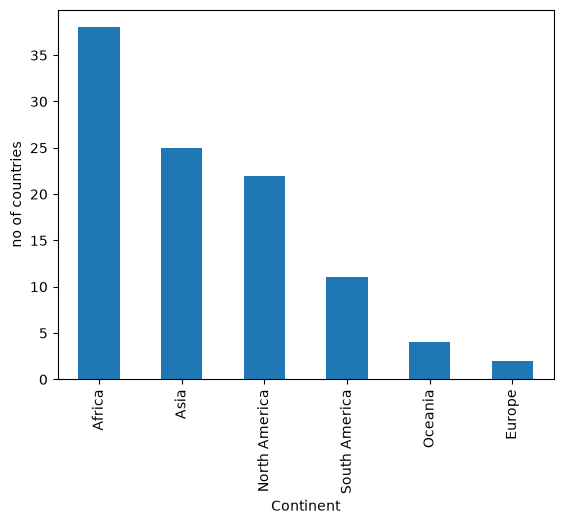

In [108]:
df["Continent"].value_counts().plot(kind = 'bar', ylabel='no of countries')

# **Distribution of columns**

C:\Users\Rishi kumar\AppData\Local\Temp\ipykernel_12960\2813586313.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production(Tons)"])
C:\Users\Rishi kumar\AppData\Local\Temp\ipykernel_12960\2813586313.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production_per_Person(Kg)"])
C

<Axes: xlabel='Yield(Kg/Hectare)', ylabel='Density'>

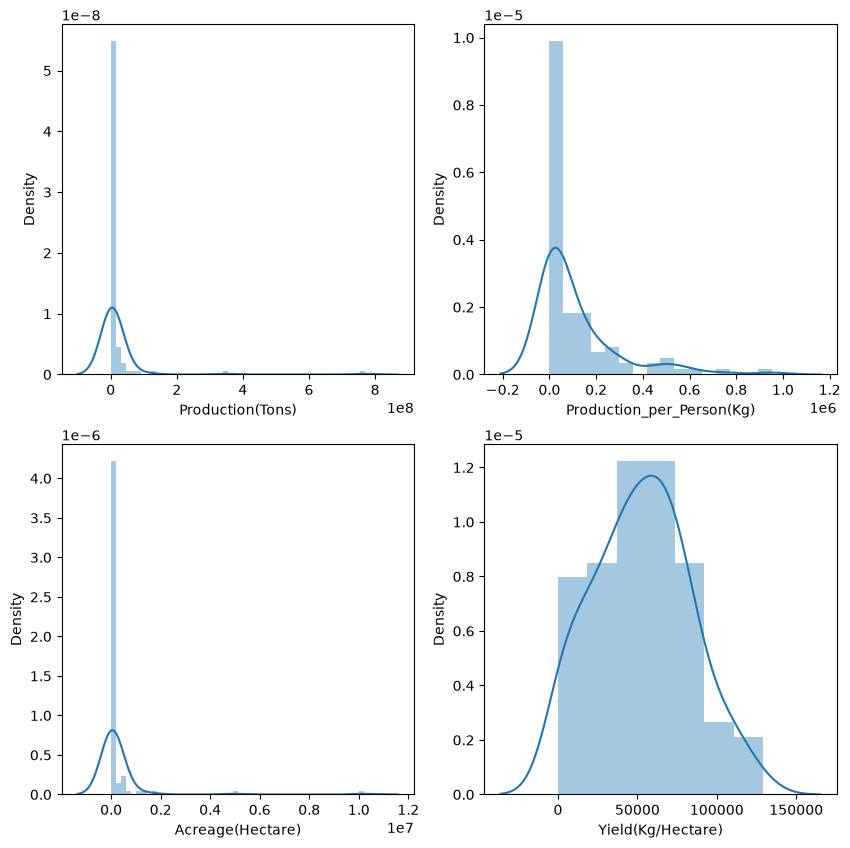

In [109]:
#now we analysis on numerical data
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.distplot(df["Production(Tons)"])
plt.subplot(2,2,2)
sns.distplot(df["Production_per_Person(Kg)"])
plt.subplot(2,2,3)
sns.distplot(df["Acreage(Hectare)"])
plt.subplot(2,2,4)
sns.distplot(df["Yield(Kg/Hectare)"])

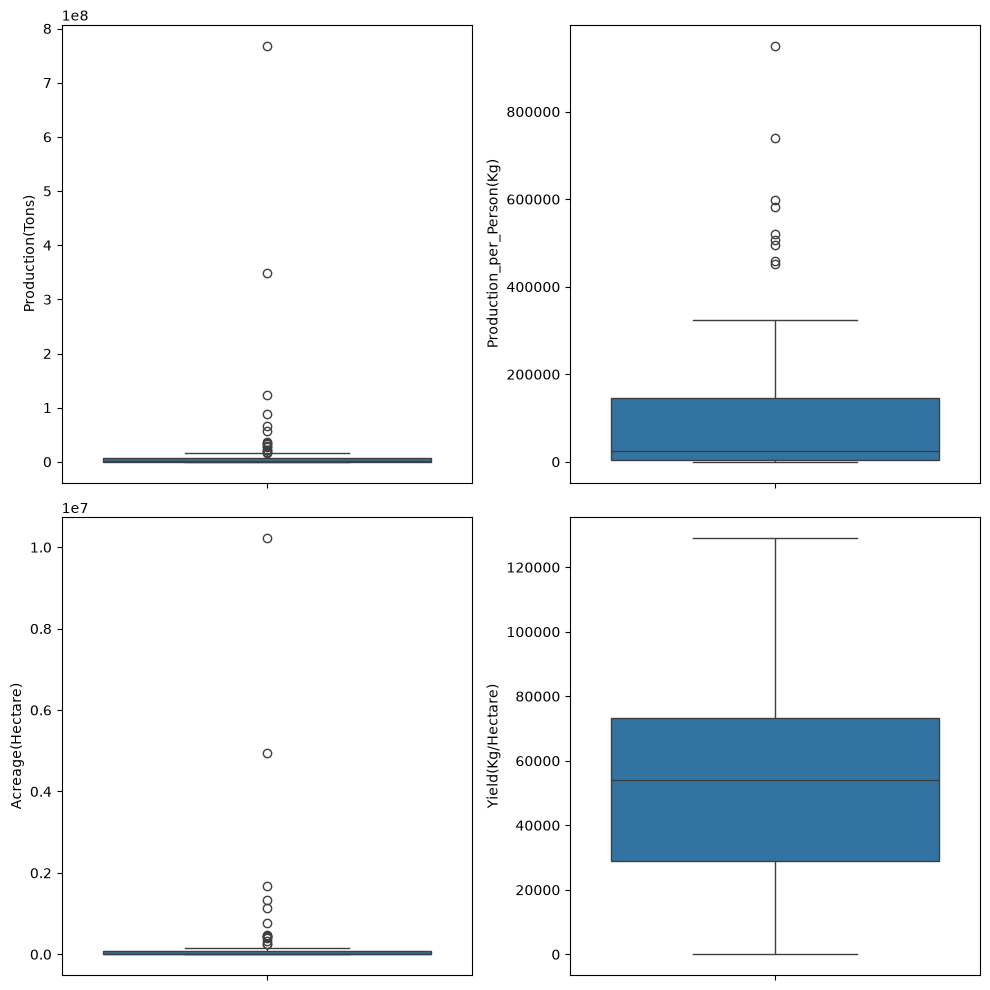

In [110]:
#checking outliers using boxplot
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.boxplot(df["Production(Tons)"])
plt.subplot(2,2,2)
sns.boxplot(df["Production_per_Person(Kg)"])
plt.subplot(2,2,3)
sns.boxplot(df["Acreage(Hectare)"])
plt.subplot(2,2,4)
sns.boxplot(df["Yield(Kg/Hectare)"])
plt.tight_layout()

In [111]:
df.describe()

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
count,1.020000e+02,102.000000,1.020000e+02,102.000000
mean,1.850372e+07,112952.435755,2.498981e+05,52628.078431
std,8.419149e+07,176651.341929,1.137003e+06,30504.676683
min,1.000000e+00,0.000000,0.000000e+00,10.000000
25%,6.251875e+04,3671.910000,1.104000e+03,29072.025000
50%,1.440044e+06,25572.500000,1.655800e+04,54108.950000
75%,6.426824e+06,146384.750000,8.047400e+04,73282.700000
max,7.686784e+08,951087.000000,1.022620e+07,129049.300000


# **BIVARIATE ANALYSIS 2 columns**

In [112]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


# **Which country produces maximum sugarcane? (using country and production tons column)**

In [113]:
df_new = df[["Country","Production(Tons)"]].set_index("Country")

In [114]:
df_new

,Production(Tons)
Country,
Brazil,768678382.0
India,348448000.0
China,123059739.0
Thailand,87468496.0
Pakistan,65450704.0
...,...
Spain,394.0
Lebanon,97.0
Singapore,50.0


In [115]:
df_new["Production(Tons)_percent"]= df_new["Production(Tons)"]*100/df_new["Production(Tons)"].sum()
df_new

,Production(Tons),Production(Tons)_percent
Country,,
Brazil,768678382.0,4.072729e+01
India,348448000.0,1.846200e+01
China,123059739.0,6.520138e+00
Thailand,87468496.0,4.634389e+00
Pakistan,65450704.0,3.467809e+00
...,...,...
Spain,394.0,2.087551e-05
Lebanon,97.0,5.139401e-06
Singapore,50.0,2.649176e-06


<Axes: >

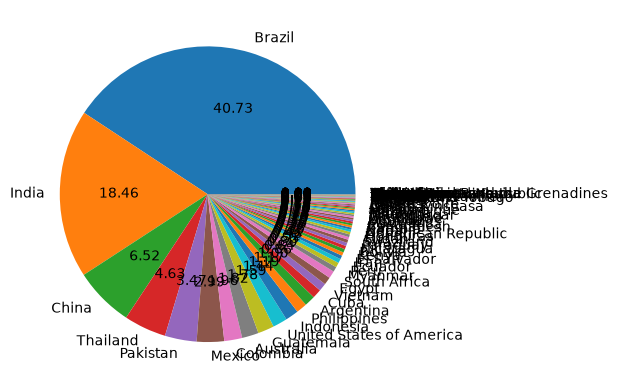

In [116]:
#plot a piechart
df_new["Production(Tons)_percent"].plot(kind="pie", autopct="%.2f")

<Axes: xlabel='Country'>

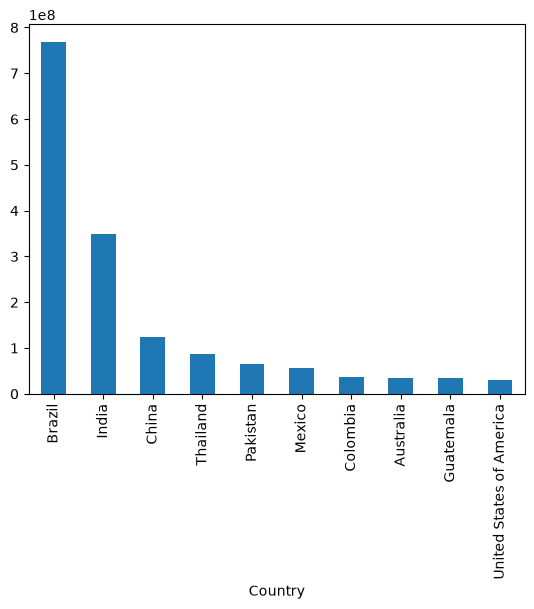

In [117]:
df_new["Production(Tons)"].head(10).plot(kind="bar")

C:\Users\Rishi kumar\AppData\Local\Temp\ipykernel_12960\2275139943.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


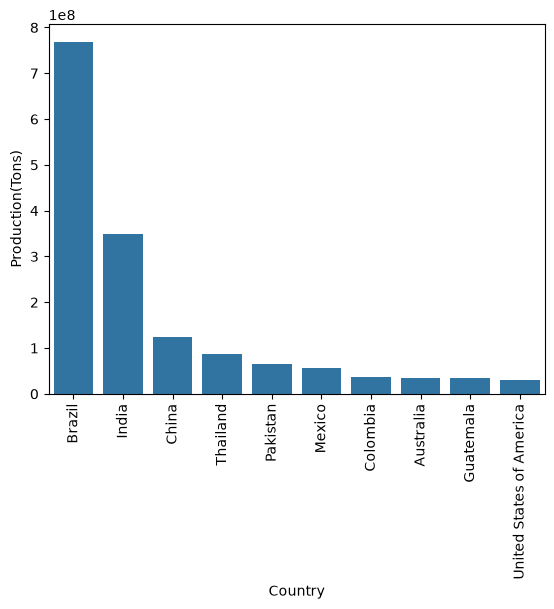

In [118]:
#using seaborn
ax= sns.barplot(data = df.head(10), x = "Country", y="Production(Tons)")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

# **Which country has highest land?**

In [119]:
#first we have to sort the values then we find highest or smallest
df_acr = df.sort_values("Acreage(Hectare)", ascending = False)

C:\Users\Rishi kumar\AppData\Local\Temp\ipykernel_12960\844557148.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


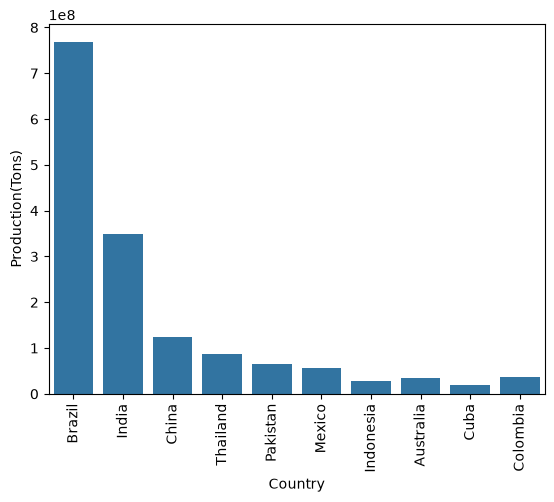

In [120]:
ax= sns.barplot(data = df_acr.head(10), x = "Country", y="Production(Tons)")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

# **Which Country has highest yield per hectare?**

In [121]:
df_yield = df.sort_values("Yield(Kg/Hectare)", ascending = False)

C:\Users\Rishi kumar\AppData\Local\Temp\ipykernel_12960\3179245314.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


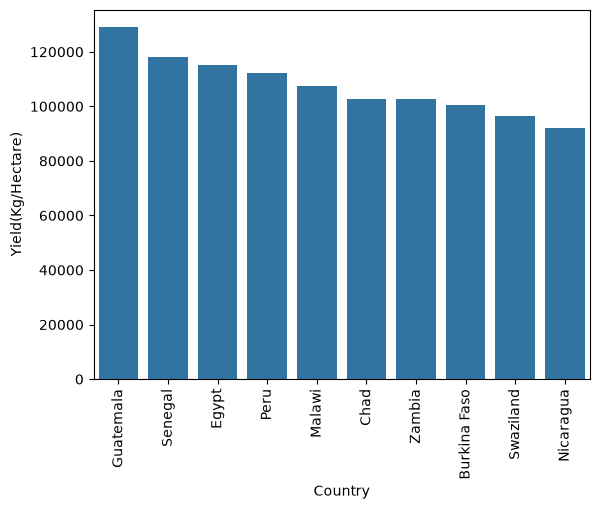

In [122]:
ax= sns.barplot(data = df_yield.head(10), x = "Country", y="Yield(Kg/Hectare)")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

Which Country has highest production?

C:\Users\Rishi kumar\AppData\Local\Temp\ipykernel_12960\3213197977.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


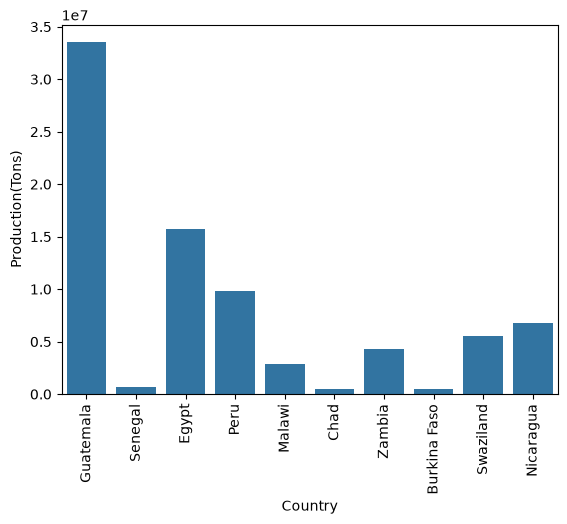

In [123]:
df_prod = df.sort_values("Production(Tons)", ascending = False)
ax= sns.barplot(data = df_yield.head(10), x = "Country", y="Production(Tons)")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

# **which country has highest production per kg?**

C:\Users\Rishi kumar\AppData\Local\Temp\ipykernel_12960\3958479423.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


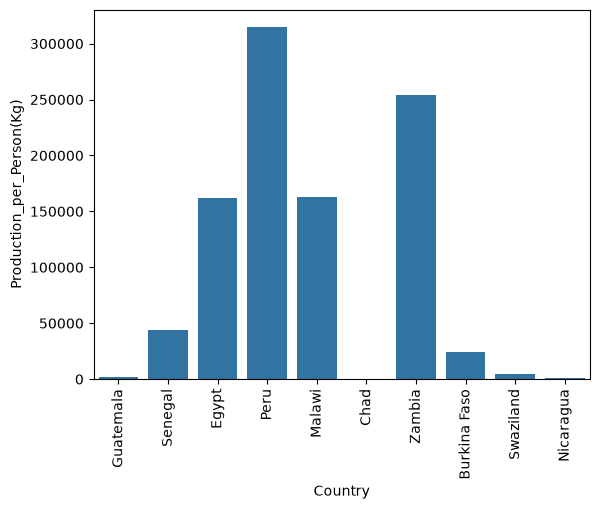

In [124]:
df_prod = df.sort_values("Production_per_Person(Kg)", ascending = False)
ax= sns.barplot(data = df_yield.head(10), x = "Country", y="Production_per_Person(Kg)")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

Correlation
closure to 0 not correlated
closure to -1 negatively correlated
closure to +1 positevely correlated

In [127]:
df.corr(numeric_only=True)

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
Production(Tons),1.000000,0.015000,0.997550,0.132812
Production_per_Person(Kg),0.015000,1.000000,0.012557,0.017999
Acreage(Hectare),0.997550,0.012557,1.000000,0.113433
Yield(Kg/Hectare),0.132812,0.017999,0.113433,1.000000


<Axes: >

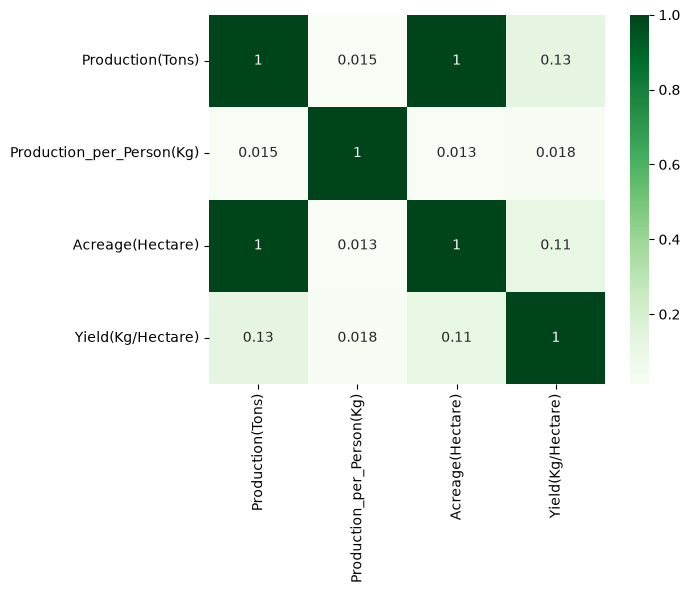

In [131]:
#using heat map to show the correlation
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap='Greens')

## **Do countries with highest land produce more sugarcane?**
Answer:- yes they are correlated

<Axes: xlabel='Acreage(Hectare)', ylabel='Production(Tons)'>

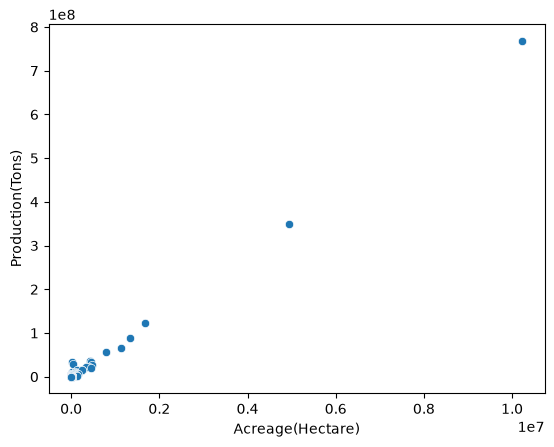

In [132]:
#usng scatterplot
sns.scatterplot(data = df, x="Acreage(Hectare)", y="Production(Tons)")

In [133]:
#land increase production increase positive correalted

## **Do countries which yield more sugarcane per hectare produces more sugarcane in total? answer :- no, because there is no correlation**

<Axes: xlabel='Yield(Kg/Hectare)', ylabel='Production(Tons)'>

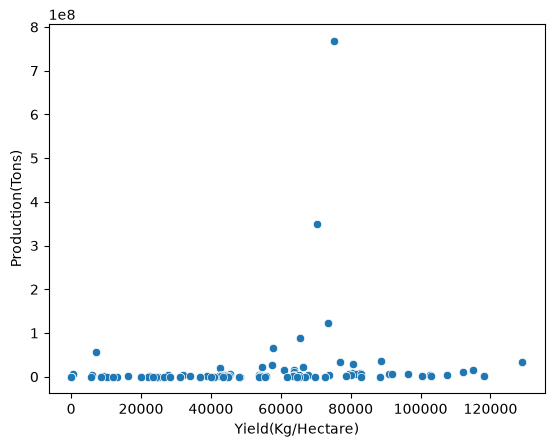

In [134]:
sns.scatterplot(data = df, x="Yield(Kg/Hectare)", y="Production(Tons)")

## **Analysis for Continent**

In [140]:
df_continent = df.groupby("Continent").sum().drop("Country", axis=1)
df_continent

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
Continent,,,,
Africa,89681472.0,2332636.293,1439089.0,2142107.5
Asia,721930425.0,1857769.303,10608319.0,1171871.4
Europe,5823.0,536.000,71.0,131870.9
North America,173995947.0,3796081.508,1581983.0,1082602.4
Oceania,36177574.0,28593.605,490909.0,162419.1
South America,865588126.0,3505531.738,11369236.0,677192.7


## **Which continent produces maximum sugarcane?**

In [143]:
df["Continent"].value_counts()

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent'>

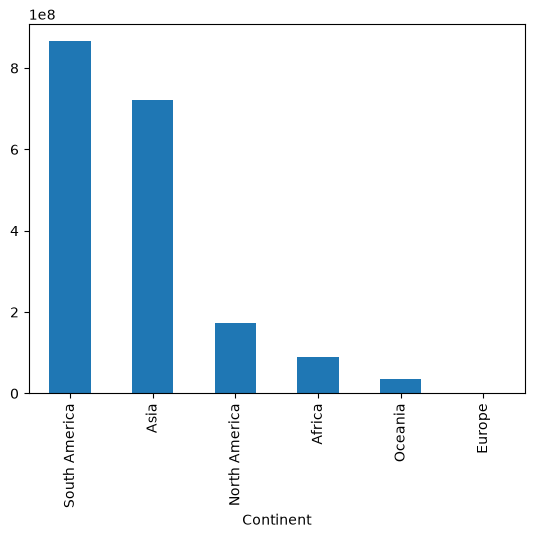

In [145]:
df_continent["Production(Tons)"].sort_values(ascending= False).plot(kind = 'bar')

## **which continent has the highest land for the production of sugar?**

<Axes: xlabel='Continent'>

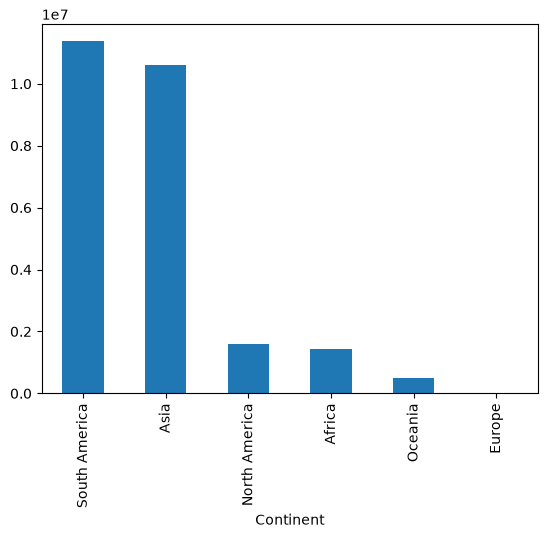

In [146]:
df_continent["Acreage(Hectare)"].sort_values(ascending= False).plot(kind = 'bar')

# **Do number of countries in a Continent effects production of sugarcane?**
answer:- no because africa has more no of countries but it comes on four number in production.

In [151]:
df_continent["number_of_countries"] = df.groupby("Continent").count()["Country"]
df_continent

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare),number_of_countries
Continent,,,,,
Africa,89681472.0,2332636.293,1439089.0,2142107.5,38
Asia,721930425.0,1857769.303,10608319.0,1171871.4,25
Europe,5823.0,536.000,71.0,131870.9,2
North America,173995947.0,3796081.508,1581983.0,1082602.4,22
Oceania,36177574.0,28593.605,490909.0,162419.1,4
South America,865588126.0,3505531.738,11369236.0,677192.7,11


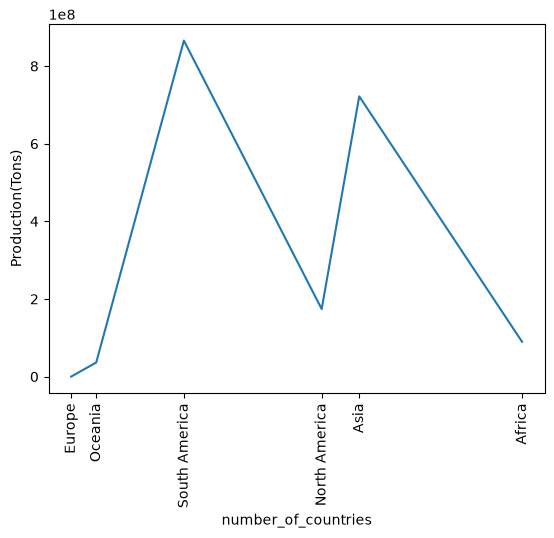

In [153]:
continents_names = df_continent.index.to_list()
sns.lineplot(data = df_continent,x = "number_of_countries", y= "Production(Tons)")
plt.xticks(df_continent["number_of_countries"], continents_names, rotation =90)
plt.show()

## **Do continent with highest land produces more sugarcane?**
(yes)

In [155]:
df_continent.corr()

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare),number_of_countries
Production(Tons),1.000000,0.522211,0.994897,0.091201,0.109244
Production_per_Person(Kg),0.522211,1.000000,0.463215,0.542961,0.540086
Acreage(Hectare),0.994897,0.463215,1.000000,0.111166,0.132817
Yield(Kg/Hectare),0.091201,0.542961,0.111166,1.000000,0.989712
number_of_countries,0.109244,0.540086,0.132817,0.989712,1.000000


## **Production distribution by continent**

<Axes: >

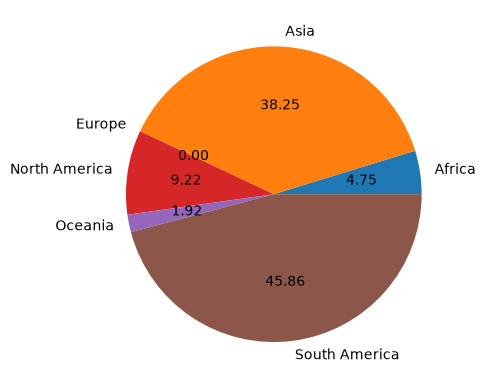

In [158]:
df_continent["Production(Tons)"].plot(kind="pie", autopct= "%.2f")

## **Conclusion**

##### The Sugarcane Production analysis provides useful insights into the global production, land utilization, and yield of sugarcane across different countries and continents. Through Exploratory Data Analysis (EDA) using Python, we identified important patterns and relationships in the dataset.

##### The analysis shows that Brazil, India, and China are among the major sugarcane-producing countries and also have large areas of land dedicated to sugarcane cultivation. A strong positive correlation was observed between production and acreage (0.997), indicating that countries with larger cultivation areas generally produce more sugarcane. However, the correlation between production and yield per hectare (0.132) was weak, showing that higher yield alone does not necessarily result in higher total production.

##### The analysis also identified Guatemala as having the highest yield per hectare and Paraguay as having the highest production per person. Continental analysis showed that South America has the highest overall sugarcane production, followed by Asia and Africa.

##### Overall, the project demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used for data cleaning, visualization, correlation analysis, and extracting meaningful insights from agricultural data. These findings can help in understanding production patterns and making better decisions regarding land utilization and agricultural efficiency.